# Seaborn

## I. Introduction

[Seaborn](https://seaborn.pydata.org/) est une librairie qui vient s'ajouter à Matplotlib. 
Seaborn vient corriger trois défauts de Matplotlib:
* Matplotlib, ne génère pas des graphiques d'une grande qualité esthétique.
* Matplotlib ne possède pas de fonctions permettant de créer facilement des analyses statistiques sophistiquées.
* Les fonctions de Matplotlib ne sont pas faites pour interagir avec les Dataframes de Pandas

Seaborn palie ces problèmes.

Ce notebook a pour objectif de vous faire explorer ces fonctionnalités.

Nous commençons par afficher des données aléatoires.

### Ressources à consulter sans modération:
* [L'API officielle](https://seaborn.pydata.org/api.html#api-reference)
* [Les tutoriels](https://seaborn.pydata.org/tutorial.html)
* [La galerie d'exemples](https://seaborn.pydata.org/examples/index.html)


Ainsi qu'un [résumé visuel](https://interactivechaos.com/sites/default/files/data/seaborn_cheat_sheet.pdf) pour rapidement identifier la fonction désirée.

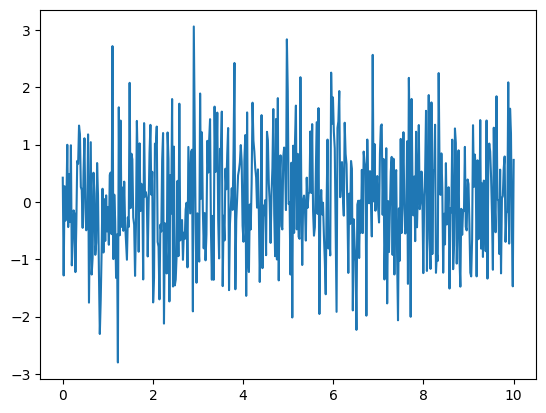

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 500)
y = np.random.randn(500)
plt.plot(x,y)

Seaborn  fournit  des fonctions pour des graphiques utiles pour l'analyse statistique. 
Par exemple, la fonction [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn-histplot)  permet non seulement de visualiser l'histogramme d'un échantillon, 
mais aussi d'estimer la distribution dont l'échantillon est issu avec l'argument *kde=True* (kernel density estimate).


### Histograms with KDE

<Axes: ylabel='Count'>

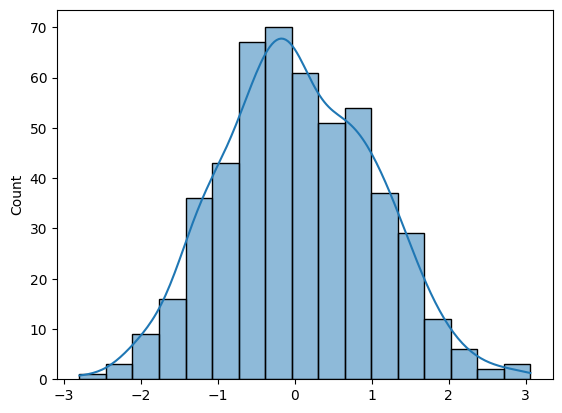

In [2]:
sns.histplot(y, kde=True)

## II. Styles de figure

- Parcourir quelques exemples de la [galerie seaborn](https://seaborn.pydata.org/examples/index.html).
  - Après l'importation de la librairie `import seaborn as sns`, vous observerez rapidement qu'ils comment tous ou presque avec l'appel de la fonction `sns.set_theme()`.
  - Cette première ligne condense déjà un gros avantage de seaborn sur matplotlib: l'apparence des figures est facilement modifiable et les options proposées sont pertinentes.
  - On va maintenant explorer ces options.

<font style="color:blue">
    
QUESTION : Quelles différences entre les plots dans les différents contextes ? 

1. Commencer par choisir un nom de  palette/échelle de couleur (=cmap en python) à partir des options [matplotlib](https://matplotlib.org/stable/tutorials/colors/colormaps.html) / [seaborn](https://seaborn.pydata.org/tutorial/color_palettes.html#palette-tutorial) existantes.
    
</font>

In [3]:
# *** TODO ***
# palette/cmap choisie:
my_colors = "Set2"                  # exemple: "viridis"
sns.color_palette(my_colors)

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

<font style="color:blue">

2. Choisir & copier maintenant un exemple de figure de la galerie seaborn *(excepté importations et sns.set_theme())* et le coller dans les deux boucles suivantes:
    
</font>

In [4]:
contexts = ["paper", "notebook", "talk", "poster"]

tips = sns.load_dataset("tips")

for c in contexts:
    sns.set_theme(context=c, palette=my_colors)
    print("context:", c)
    
    # TODO: coller ici
    # *********************************
    
    # *********************************
    plt.show()

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

NB: Si votre échelle de couleur n'est pas appliquée, c'est probablement qu'un/plusieurs `color` ou `cmap` l'a écrasé dans votre exemple, essayez alors de les supprimer.

<span style="color:blue">QUESTION : Quelles différences entre les plots dans les différents contextes ? </span> 

<font color='red'>

Taille des figures, taille des traits, ...

</font>    
 



In [ ]:
styles   = ["darkgrid", "whitegrid", "dark", "white", "ticks"]

for s in styles:
    sns.set_theme(context="notebook", style=s , palette=my_colors)
    print("style:", s)
    
    # TODO: coller ici
    # *********************************
    
    sns.violinplot(data=tips, x="day", y="total_bill", hue="smoker",
                   split=True, inner="quart", fill=False)       
    
    # *********************************
    plt.show()

3. Vous l'aurez compris, le but avec cette fonction est de définir au début de votre script de figures et une fois pour toute leurapparrence désirée. 
4. `sns.set_theme()` présente d'autres arguments que vous pouvez tester si envie!
5. `sns.set()` est un alias pour `sns.set_theme()` qui mettent donc tous deux en place les paramètres par défaut.

## III. Structure de données acceptées par Seaborn

![data_structures](data_structures.png)
[source](https://seaborn.pydata.org/tutorial/data_structure.html#long-form-vs-wide-form-data)

<font style="color:blue">

- **Lire les paragraphes *Long-form data* et *Wide-form data* de la page [Data structures accepted by seaborn](https://seaborn.pydata.org/tutorial/data_structure.html#data-structures-accepted-by-seaborn)**.
  
  Cette difference est fondamentale pour bien manipuler les fonctions de visualisations.

</font>

- **Long-form** (=tidy classiquement):
  - Chaque variable est une colonne
  - Chaque ligne est une observation
  - On peut accumuler facilement de nombreuses variables en ajoutant de nouvelles colonnes.
  
  $\rightarrow$ On peut accéder à la valeur d'une variable simplement à partir de son index (souvent un entier ou un nom).



- **Wide-form** (=données dans un tableau à deux entrées, typique dans un tableur):
  - Les colonnes contiennent *les niveaux* d'une variable
  - Les lignes contiennent les niveaux d'*une autre variable*
  - Seules 3 variables peuvent être représentées simplement avec cette structure (indexs multiples nécessaires au delà de 3 variables)

      $\rightarrow$ Pour accéder à la valeur d'une variable, on a besoin d'identifier à la fois son niveau de ligne et son niveau de colonne.


## IV. Iris dataset

![Petal/Sepal difference wikipedia](petal-sepal-wiki.jpg)
[source](https://fr.wikipedia.org/wiki/S%C3%A9pale)

Imaginons que nous voulons travailler sur un ensemble de données provenant du jeu de données "Iris", 
qui contient des mesures de la longueur et la largeur des sépales et des pétales de trois espèces d'iris. 
C'est un jeu de données très souvent utilisé pour se faire la main sur des problèmes de machine learning.

In [5]:
sns.set()
iris = sns.load_dataset("iris")
# Afficher les dimensions et le début des données iris
print(iris.shape)
iris.head()

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

### Pair plots

In [6]:
# Pour voir les relations entre ces caractéristiques, on peut faire des graphiques par paire :
sns.pairplot(iris, hue='species', height=2.5)

NameError: name 'iris' is not defined

<span style="color:blue">QUESTION : Pourquoi les graphes sur la diagonale sont-ils des histogrammes ? 
Que pouvez-vous dire des relations entre les différentes caractéristiques ? 
 Et sur les différences entre les espèces ? </span> \
<span style="color:red">
XXXXXXXXXXX </span>

### Joint distributions

Nous pouvons aussi voir la distribution jointe de ces deux caractéristiques avec la fonction jointplot:

In [7]:
with sns.axes_style('white'):
    sns.jointplot(data=iris, x="petal_length", y="petal_width",  kind='reg')


NameError: name 'iris' is not defined

<span style="color:blue">QUESTION : comment interprétez vous ce graphique ? </span> 

<font color='red'>

XXXXXXXXXXXX    
</font>    
 



## V. A lot of examples!

<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="PDSH-cover-small.png">

*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

### A little bit more of context

Matplotlib has proven to be an incredibly useful and popular visualization tool, but even avid users will admit it often leaves much to be desired.
There are several valid complaints about Matplotlib that often come up:

- Prior to version 2.0, Matplotlib's defaults are not exactly the best choices. It was based off of MATLAB circa 1999, and this often shows.
- Matplotlib's API is relatively low level. Doing sophisticated statistical visualization is possible, but often requires a *lot* of boilerplate code.
- Matplotlib predated Pandas by more than a decade, and thus is not designed for use with Pandas ``DataFrame``s. In order to visualize data from a Pandas ``DataFrame``, you must extract each ``Series`` and often concatenate them together into the right format. It would be nicer to have a plotting library that can intelligently use the ``DataFrame`` labels in a plot.

An answer to these problems is [Seaborn](http://seaborn.pydata.org/). Seaborn provides an API on top of Matplotlib that offers sane choices for plot style and color defaults, defines simple high-level functions for common statistical plot types, and integrates with the functionality provided by Pandas ``DataFrame``s.

To be fair, the Matplotlib team is addressing this: it has recently added the ``plt.style`` tools discussed in [Customizing Matplotlib: Configurations and Style Sheets](https://jakevdp.github.io/PythonDataScienceHandbook/04.11-settings-and-stylesheets.html), and is starting to handle Pandas data more seamlessly.
The 2.0 release of the library will include a new default stylesheet that will improve on the current status quo.
But for all the reasons just discussed, Seaborn remains an extremely useful addon.

### Seaborn Versus Matplotlib

Here is an example of a simple random-walk plot in Matplotlib, using its classic plot formatting and colors.
We start with the typical imports:

In [8]:
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline
import numpy as np
import pandas as pd

Now we create some random walk data:

In [9]:
# Create some data
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 500)
y = np.cumsum(rng.randn(500, 6), 0)

And do a simple plot:

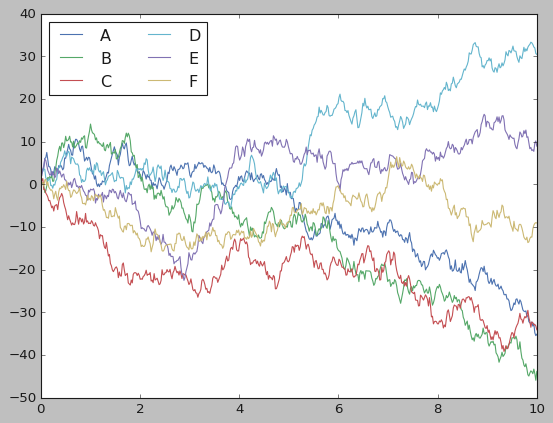

In [10]:
# Plot the data with Matplotlib defaults
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left')

Although the result contains all the information we'd like it to convey, it does so in a way that is not all that aesthetically pleasing, and even looks a bit old-fashioned in the context of 21st-century data visualization.

Now let's take a look at how it works with Seaborn.
As we will see, Seaborn has many of its own high-level plotting routines, but it can also overwrite Matplotlib's default parameters and in turn get even simple Matplotlib scripts to produce vastly superior output.
We can set the style by calling Seaborn's ``set()`` method.
By convention, Seaborn is imported as ``sns``:

In [11]:
import seaborn as sns
sns.set(rc={'figure.figsize':(11.7,8.27)})

Now let's rerun the same two lines as before:

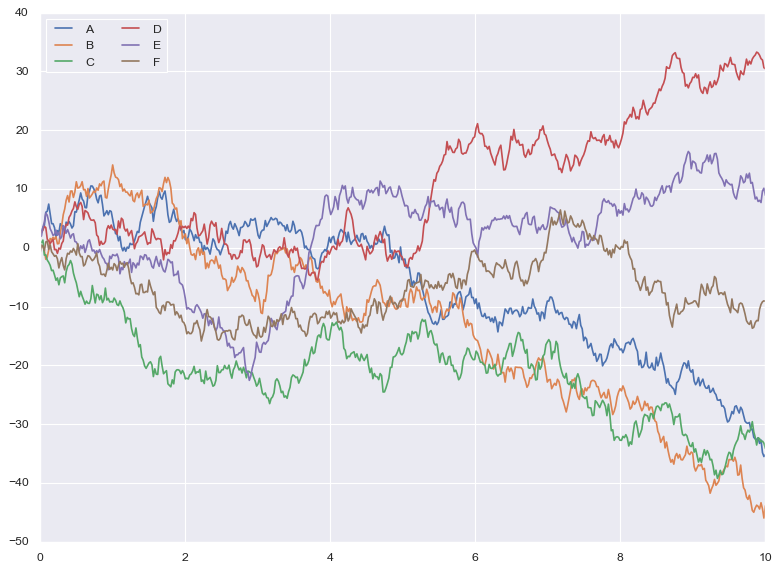

In [12]:
# same plotting code as above!
plt.plot(x, y)
plt.legend('ABCDEF', ncol=2, loc='upper left')

Ah, much better!

### Exploring Seaborn Plots

The main idea of Seaborn is that it provides high-level commands to create a variety of plot types useful for statistical data exploration, and even some statistical model fitting.

Let's take a look at a few of the datasets and plot types available in Seaborn. Note that all of the following *could* be done using raw Matplotlib commands (this is, in fact, what Seaborn does under the hood) but the Seaborn API is much more convenient.

### KDE, and densities

Often in statistical data visualization, all you want is to plot histograms and joint distributions of variables.
We have seen that this is relatively straightforward in Matplotlib:

In [13]:
data = np.random.multivariate_normal([0, 0], [[5, 2], [2, 2]], size=2000)
data = pd.DataFrame(data, columns=['x', 'y'])
print(data.shape)
data

(2000, 2)


,x,y
0,1.251844,-0.459196
1,-0.495009,0.414818
2,-2.081049,-3.101982
3,3.710214,1.902299
4,-3.212344,-2.911699
...,...,...
1995,6.330298,3.156023
1996,0.346392,-0.876196
1997,1.545150,-1.518004
1998,2.241839,0.744046


We can get a smooth estimate of the distribution using a kernel density estimation, which Seaborn does with ``sns.kdeplot`` (same as sns.hist() with kde=True previously viewed):

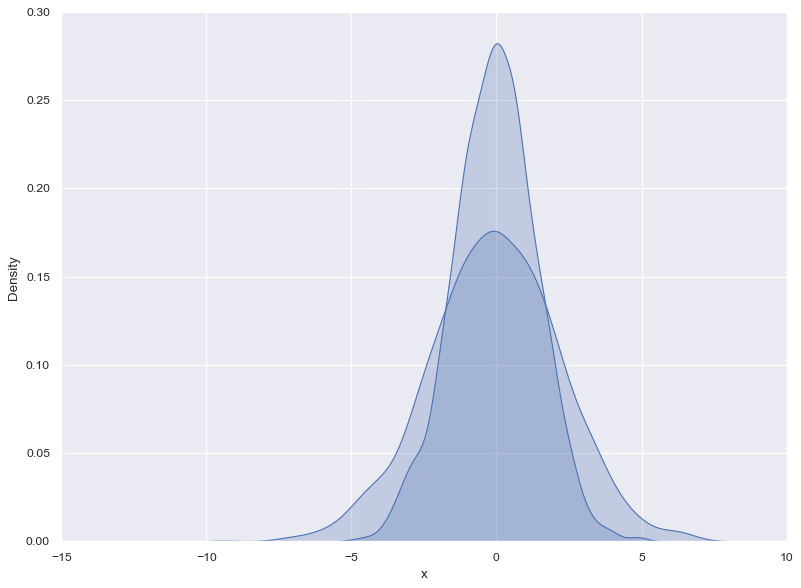

In [14]:
for col in 'xy':
    sns.kdeplot(data[col], fill=True)

If we pass the full two-dimensional dataset to ``kdeplot``, we will get a two-dimensional visualization of the data:

<Axes: xlabel='x', ylabel='y'>

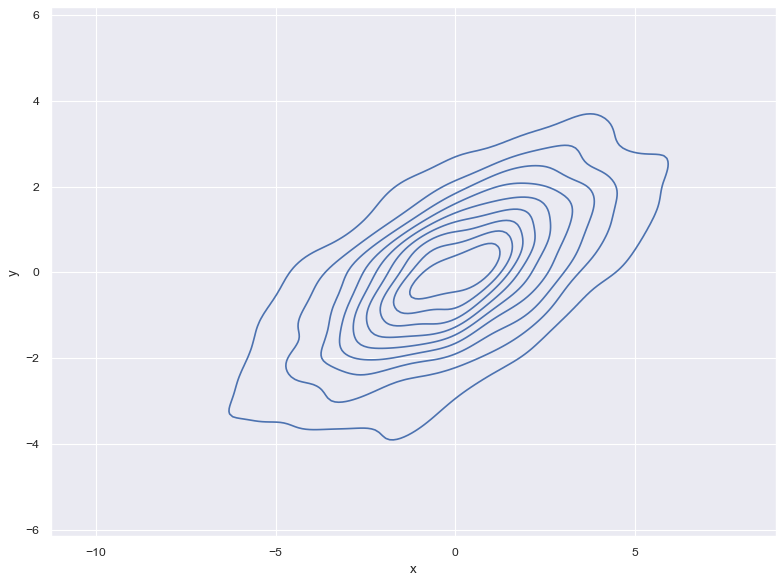

In [15]:
sns.kdeplot(data=data, x="x", y="y")

We can see the joint distribution and the marginal distributions together using ``sns.jointplot``.
For this plot, we'll set the style to a white background:

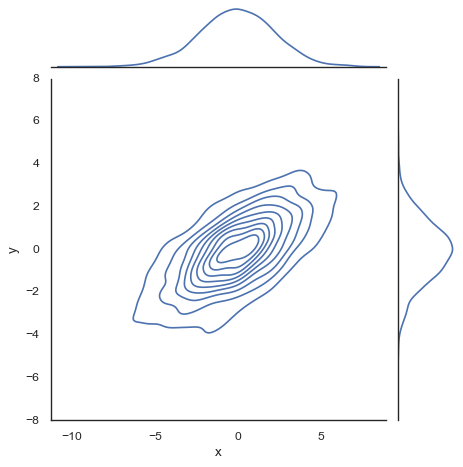

In [16]:
with sns.axes_style('white'):
    sns.jointplot(x="x", y="y", data=data, kind='kde');

There are other parameters that can be passed to ``jointplot``—for example, we can use a hexagonally based histogram instead:

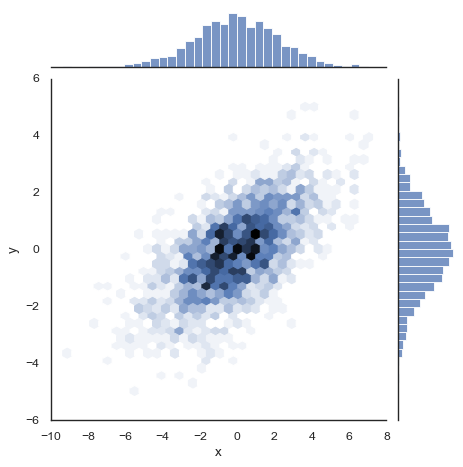

In [17]:
with sns.axes_style('white'):
    sns.jointplot(x="x", y="y", data=data, kind='hex')

### Faceted histograms

Sometimes the best way to view data is via histograms of subsets. Seaborn's ``FacetGrid`` makes this extremely simple.
We'll take a look at some data that shows the amount that restaurant staff receive in tips based on various indicator data:

In [18]:
tips = sns.load_dataset('tips')
print(tips.shape)
tips.head(15)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

In [19]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

grid = sns.FacetGrid(tips, row="smoker", col="time", margin_titles=True)
grid.map(sns.histplot, "tip_pct", bins=np.linspace(0, 40, 20));

NameError: name 'tips' is not defined

In [20]:
tips.groupby("smoker").size()

NameError: name 'tips' is not defined

In [21]:
tips.groupby("time").size()

NameError: name 'tips' is not defined

<font style="color:blue">

QUESTION : Les groupes représentés n'ayant pas les mêmes effectifs, il est difficile de comparer les histogrammes sur la visualisation précédente.
1. Par quelle fonction remplacer sns.histplot() pour s'affranchir de la taille des quatre échantillons et pouvoir comparer leurs distributions?
2. Repéter le sns.FacetGrid() avec cette nouvelle fonction.
3. Tester des nouvelles paires de variables avec cette visualisation, il y a t'il des interprétations possibles?
</font> 

In [22]:
# TODO

grid = sns.FacetGrid(tips, row="smoker", col="time", margin_titles=True)
grid.map(sns.kdeplot, "tip_pct");

NameError: name 'tips' is not defined

### Cat plots

Factor plots can be useful for this kind of visualization as well. This allows you to view the distribution of a parameter within bins defined by any other parameter:

In [23]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(x="day", y="total_bill", hue="time", data=tips, kind="box")
    g.set_axis_labels("Day", "Total Bill");

NameError: name 'tips' is not defined

### Joint distributions

Similar to the pairplot we saw earlier, we can use ``sns.jointplot`` to show the joint distribution between different datasets, along with the associated marginal distributions:

In [24]:
with sns.axes_style('white'):
    sns.jointplot(x="total_bill", y="tip", data=tips, kind='hex')

NameError: name 'tips' is not defined

The joint plot can even do some automatic kernel density estimation and regression:

In [25]:
sns.jointplot(x="total_bill", y="tip", data=tips, kind='reg');

NameError: name 'tips' is not defined

### Bar plots

Time series can be plotted using ``sns.catplot``. In the following example, we'll use the Planets dataset.

In [26]:
planets = sns.load_dataset('planets')
print(planets.shape)
planets.head(5)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

In [ ]:
with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=2,
                       kind="count", color='steelblue')
    g.set_xticklabels(step=5)

We can learn more by looking at the *method* of discovery of each of these planets (Zoom to better appreciate the figure):

In [27]:
with sns.axes_style('white'):
    g = sns.catplot(x="year", data=planets, aspect=3.0, kind='count',
                       hue='method', order=range(2001, 2015))
    g.set_ylabels('Number of Planets Discovered')

NameError: name 'planets' is not defined

### Example: Exploring Marathon Finishing Times

Here we'll look at using Seaborn to help visualize and understand finishing results from a marathon.

We will start by downloading the data from the Web, and loading it into Pandas:

In [28]:
!curl -O https://raw.githubusercontent.com/jakevdp/marathon-data/master/marathon-data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  836k  100  836k    0     0   214k      0  0:00:03  0:00:03 --:--:--  214k


In [29]:
data = pd.read_csv('marathon-data.csv')
print(data.shape)
data.head()

(37250, 4)


,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59


By default, Pandas loaded the time columns as Python strings (type ``object``); we can see this by looking at the ``dtypes`` attribute of the DataFrame:

In [30]:
data.dtypes

age        int64
gender    object
split     object
final     object
dtype: object

Let's fix this by providing a converter for the times:

In [31]:
import datetime

def convert_time(s):
    h, m, s = map(int, s.split(':'))
    return datetime.timedelta(hours=h, minutes=m, seconds=s)

data = pd.read_csv('marathon-data.csv',
                   converters={'split':convert_time, 'final':convert_time})
data.head()

,age,gender,split,final
0,33,M,0 days 01:05:38,0 days 02:08:51
1,32,M,0 days 01:06:26,0 days 02:09:28
2,31,M,0 days 01:06:49,0 days 02:10:42
3,38,M,0 days 01:06:16,0 days 02:13:45
4,31,M,0 days 01:06:32,0 days 02:13:59


In [32]:
data.dtypes

age                 int64
gender             object
split     timedelta64[ns]
final     timedelta64[ns]
dtype: object

That looks much better. For the purpose of our Seaborn plotting utilities, let's next add columns that give the times in seconds:

In [33]:
data['split_sec'] = data['split'].astype(int) / 1e9
data['final_sec'] = data['final'].astype(int) / 1e9
data.head()

,age,gender,split,final,split_sec,final_sec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0


To get an idea of what the data looks like, we can plot a ``jointplot`` over the data:

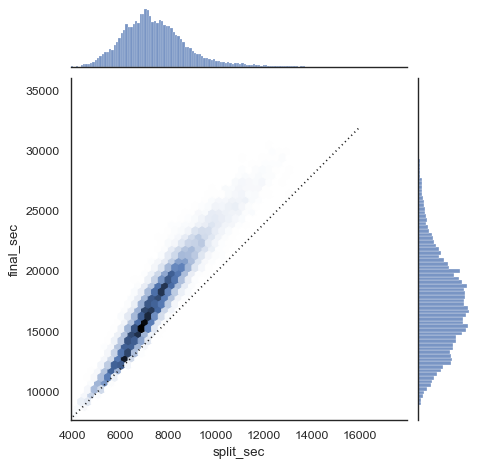

In [34]:
with sns.axes_style('white'):
    g = sns.jointplot(x="split_sec", y="final_sec", data=data, kind='hex')
    g.ax_joint.plot(np.linspace(4000, 16000),
                    np.linspace(8000, 32000), ':k')

The dotted line shows where someone's time would lie if they ran the marathon at a perfectly steady pace. The fact that the distribution lies above this indicates (as you might expect) that most people slow down over the course of the marathon.
If you have run competitively, you'll know that those who do the opposite—run faster during the second half of the race—are said to have "negative-split" the race.

Let's create another column in the data, the split fraction, which measures the degree to which each runner negative-splits or positive-splits the race:

In [35]:
data['split_frac'] = 1 - 2 * data['split_sec'] / data['final_sec']
data.head()

,age,gender,split,final,split_sec,final_sec,split_frac
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842


Where this split difference is less than zero, the person negative-split the race by that fraction.
Let's do a distribution plot of this split fraction:

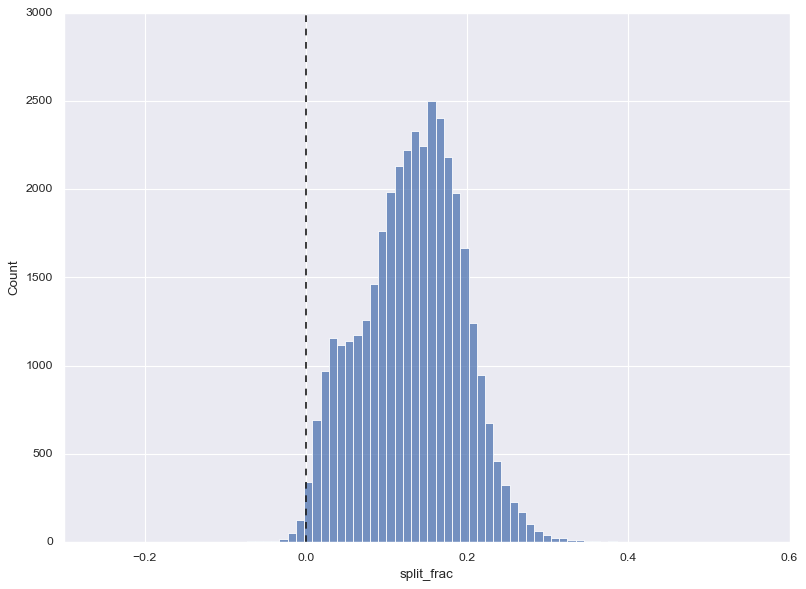

In [36]:
sns.histplot(data['split_frac'], kde=False, bins=80);
plt.axvline(0, color="k", linestyle="--");

In [37]:
sum(data.split_frac < 0)

251

Out of nearly 40,000 participants, there were only 250 people who negative-split their marathon.

Let's see whether there is any correlation between this split fraction and other variables. We'll do this using a ``pairplot``, which draws plots of all these correlations:

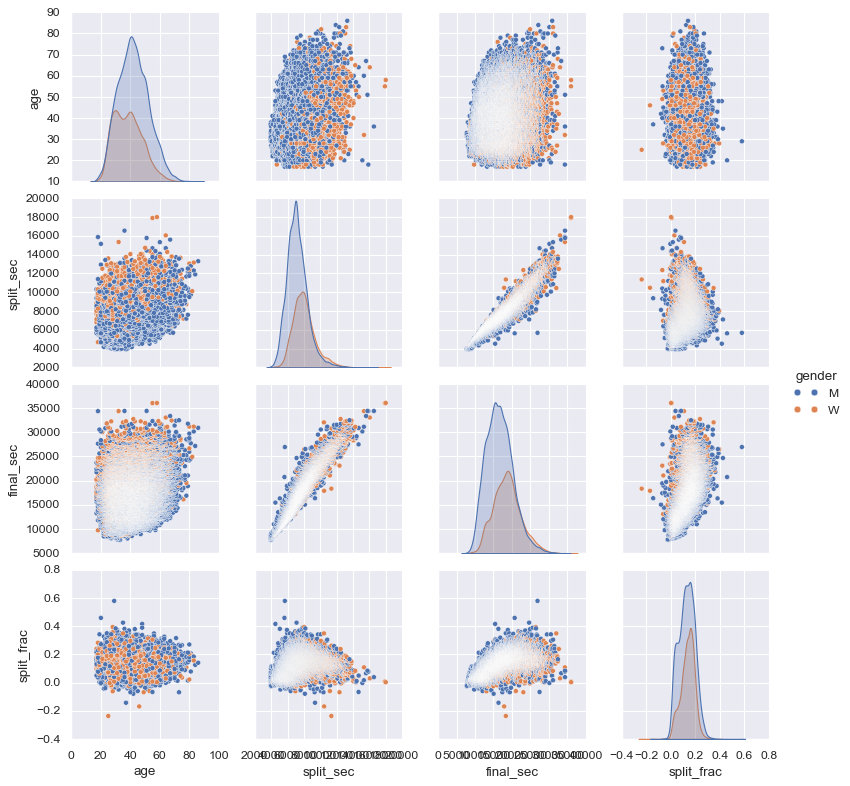

In [38]:
sns.pairplot(data, hue='gender', height=2.5)

It looks like the split fraction does not correlate particularly with age, but does correlate with the final time: faster runners tend to have closer to even splits on their marathon time.

We see here that Seaborn is no panacea for Matplotlib's ills when it comes to plot styles: in particular, the x-axis labels overlap. It could nonetheless be adjusted if desired.

Let's look at the histogram of age between men and women:

<Axes: xlabel='age', ylabel='Count'>

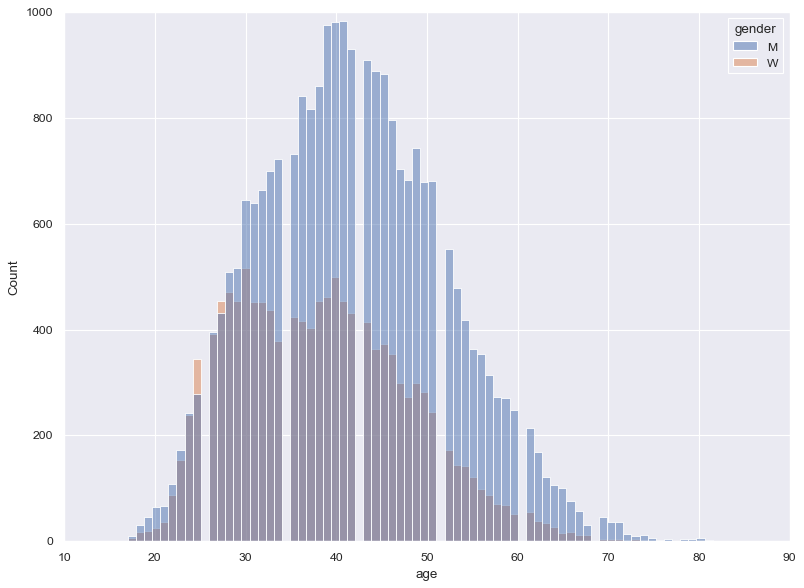

In [39]:
sns.histplot(x="age", hue="gender", data=data)

Another nice way to compare distributions is to use a *violin plot*:

<Axes: xlabel='age', ylabel='gender'>

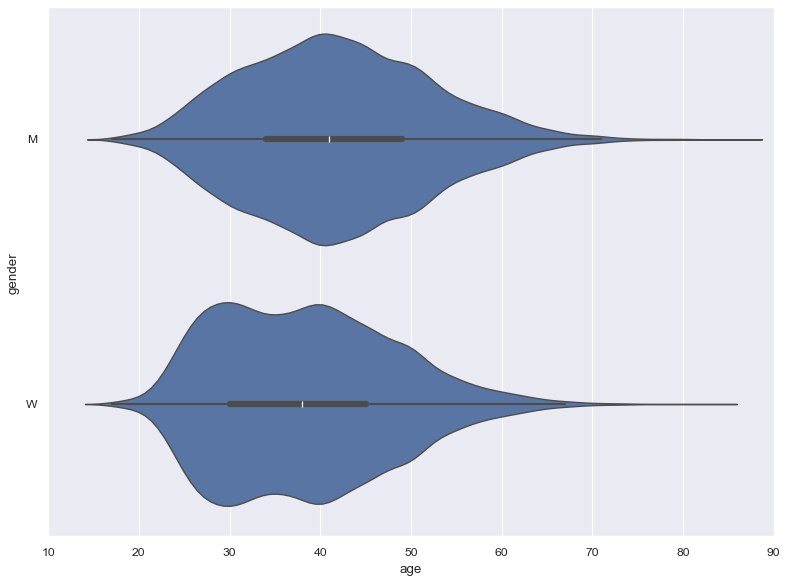

In [40]:
sns.violinplot(x="age", y="gender", data=data)

Let's now explore final times in function of the age decade and sex:

In [41]:
data['age_dec'] = data.age.map(lambda age: 10 * (age // 10))
data.head()

,age,gender,split,final,split_sec,final_sec,split_frac,age_dec
0,33,M,0 days 01:05:38,0 days 02:08:51,3938.0,7731.0,-0.018756,30
1,32,M,0 days 01:06:26,0 days 02:09:28,3986.0,7768.0,-0.026262,30
2,31,M,0 days 01:06:49,0 days 02:10:42,4009.0,7842.0,-0.022443,30
3,38,M,0 days 01:06:16,0 days 02:13:45,3976.0,8025.0,0.009097,30
4,31,M,0 days 01:06:32,0 days 02:13:59,3992.0,8039.0,0.006842,30


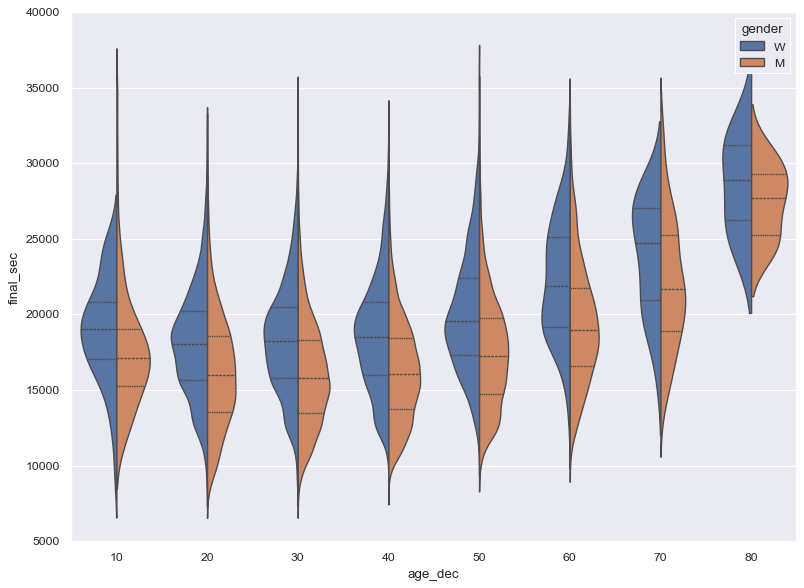

In [42]:
with sns.axes_style(style=None):
    sns.violinplot(x="age_dec", y="final_sec", hue="gender", data=data,
                   split=True, inner="quartile");